In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set visual style for our charts
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load the dataset using standard comma separation
df = pd.read_csv("bank.csv")

# 1. Dataset Overview: Number of rows and columns
print(f"Dataset Shape (Rows, Columns): {df.shape}")

# 2. Preview the first 5 rows
display(df.head())

# 3. Data Types & Missing Values Assessment
print("\n--- Data Info & Missing Values ---")
print(df.info())
print("\nMissing Values Count per Column:")
print(df.isnull().sum())

Dataset Shape (Rows, Columns): (11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes



--- Data Info & Missing Values ---
<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB
None

Missing Values Count per Column:
age          0
job          0
marital      0
education    

C:\Users\user\AppData\Local\Temp\ipykernel_17636\4055647435.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\user\AppData\Local\Temp\ipykernel_17636\4055647435.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\user\AppData\Local\Temp\ipykernel_17636\4055647435.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


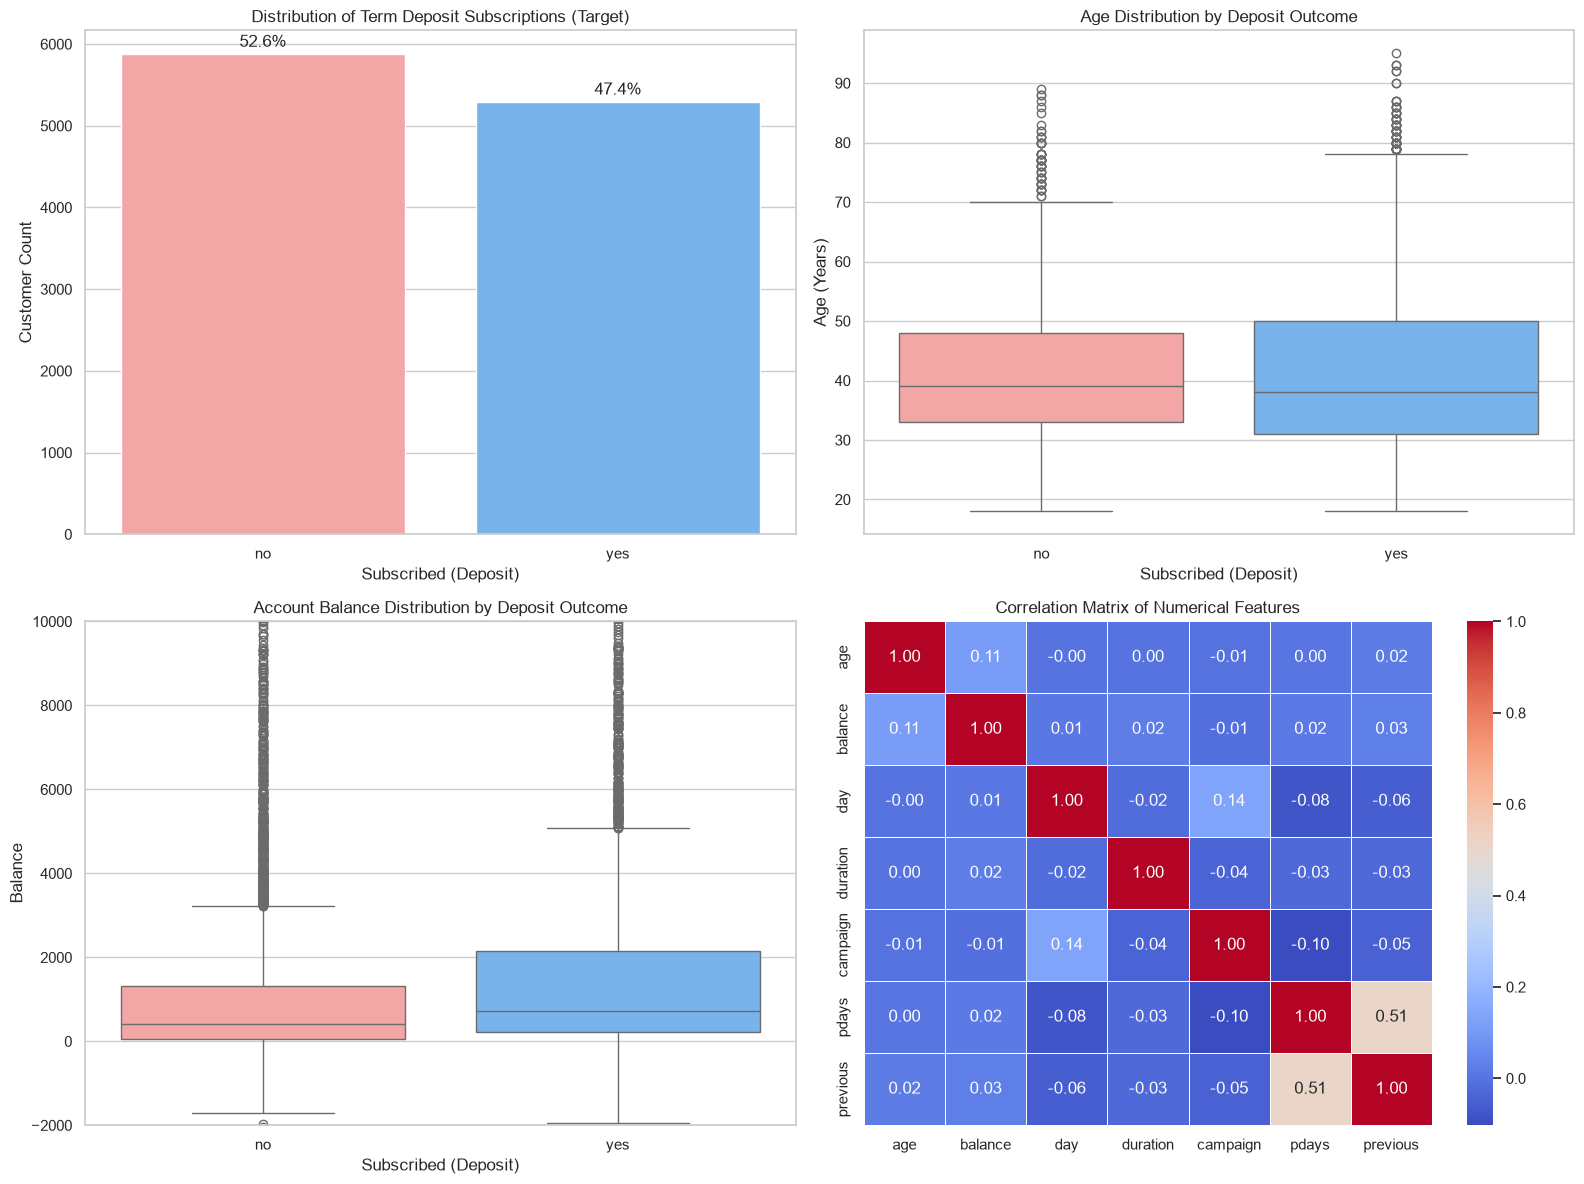

In [3]:
# Create a new figure with multiple subplots for EDA
fig = plt.figure(figsize=(16, 12))

# 1. Target Variable Distribution (Deposit)
plt.subplot(2, 2, 1)
ax = sns.countplot(
    x="deposit", data=df, palette=["#ff9999", "#66b3ff"], order=["no", "yes"]
)
plt.title("Distribution of Term Deposit Subscriptions (Target)")
plt.xlabel("Subscribed (Deposit)")
plt.ylabel("Customer Count")
for p in ax.patches:
    percentage = f"{100 * p.get_height() / len(df):.1f}%"
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
    )

# 2. Age Distribution by Deposit Outcome
plt.subplot(2, 2, 2)
sns.boxplot(
    x="deposit",
    y="age",
    data=df,
    palette=["#ff9999", "#66b3ff"],
    order=["no", "yes"],
)
plt.title("Age Distribution by Deposit Outcome")
plt.xlabel("Subscribed (Deposit)")
plt.ylabel("Age (Years)")

# 3. Balance vs Deposit Outcome
plt.subplot(2, 2, 3)
sns.boxplot(
    x="deposit",
    y="balance",
    data=df,
    palette=["#ff9999", "#66b3ff"],
    order=["no", "yes"],
)
plt.title("Account Balance Distribution by Deposit Outcome")
plt.xlabel("Subscribed (Deposit)")
plt.ylabel("Balance")
# Limiting y-axis outliers for clearer visualization of the bulk data
plt.ylim(-2000, 10000)

# 4. Correlation Heatmap for Numerical Features
plt.subplot(2, 2, 4)
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()
sns.heatmap(
    corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar=True
)
plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()